# Experiment 1: Descriptive & Inferential Statistics

**Case Study:** Customer Segmentation (Online Retail Dataset)

**AIM:** Explore the descriptive and inferential statistics on the given dataset.

**Dataset:** [Kaggle - Customer Segmentation Dataset](https://www.kaggle.com/datasets/yasserh/customer-segmentation-dataset)

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data_online_retail.csv', encoding='latin1')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print("Shape:", df.shape)
df.head()

Shape: (541909, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


## Part A: Descriptive Statistics

In [2]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# --- Basic descriptive stats ---
desc = pd.DataFrame(index=numeric_cols)
desc['Mean'] = df[numeric_cols].mean()
desc['Median'] = df[numeric_cols].median()
desc['Mode'] = df[numeric_cols].mode().iloc[0]
desc['Min'] = df[numeric_cols].min()
desc['Max'] = df[numeric_cols].max()
desc['Sum'] = df[numeric_cols].sum()
desc['Range'] = desc['Max'] - desc['Min']
desc['Q1'] = df[numeric_cols].quantile(0.25)
desc['Q3'] = df[numeric_cols].quantile(0.75)
desc['IQR'] = desc['Q3'] - desc['Q1']
desc['Std Dev'] = df[numeric_cols].std()
desc['Variance'] = df[numeric_cols].var()

print("=== Basic Descriptive Statistics ===")
desc

=== Basic Descriptive Statistics ===


,Mean,Median,Mode,Min,Max,Sum,Range,Q1,Q3,IQR,Std Dev,Variance
Quantity,9.552250,3.00,1.00,-80995.00,80995.0,5.176450e+06,161990.00,1.00,10.00,9.00,218.081158,4.755939e+04
UnitPrice,4.611114,2.08,1.25,-11062.06,38970.0,2.498804e+06,50032.06,1.25,4.13,2.88,96.759853,9.362469e+03
CustomerID,15287.690570,15152.00,17841.00,12346.00,18287.0,6.219476e+09,5941.00,13953.00,16791.00,2838.00,1713.600303,2.936426e+06
TotalPrice,17.987795,9.75,15.00,-168469.60,168469.6,9.747748e+06,336939.20,3.40,17.40,14.00,378.810824,1.434976e+05


In [3]:
# --- Advanced descriptive stats ---
adv = pd.DataFrame(index=numeric_cols)
n = df[numeric_cols].count()
adv['SE of Mean'] = df[numeric_cols].std() / np.sqrt(n)
adv['Coeff of Variation'] = (df[numeric_cols].std() / df[numeric_cols].mean()) * 100
adv['N Missing'] = df[numeric_cols].isnull().sum()
adv['N Total'] = len(df)
adv['Cumulative N'] = adv['N Total'] - adv['N Missing']
adv['Percent'] = (n / len(df)) * 100
adv['Cumulative Percent'] = adv['Percent'].cumsum()
adv['Trimmed Mean'] = [stats.trim_mean(df[col].dropna(), 0.1) for col in numeric_cols]
adv['Sum of Squares'] = [(df[col].dropna()**2).sum() for col in numeric_cols]
adv['Skewness'] = df[numeric_cols].skew()
adv['Kurtosis'] = df[numeric_cols].kurtosis()

print("=== Advanced Descriptive Statistics ===")
adv

=== Advanced Descriptive Statistics ===


,SE of Mean,Coeff of Variation,N Missing,N Total,Cumulative N,Percent,Cumulative Percent,Trimmed Mean,Sum of Squares,Skewness,Kurtosis
Quantity,0.296248,2283.034554,0,541909,541909,100.000000,100.000000,5.197809,2.582226e+10,-0.264076,119769.160031
UnitPrice,0.131441,2098.405307,0,541909,541909,100.000000,200.000000,2.600625,5.085119e+09,186.506972,59005.719097
CustomerID,2.686604,11.209020,135080,541909,406829,75.073306,275.073306,15288.247351,9.627604e+13,0.029835,-1.179982
TotalPrice,0.514587,2105.932529,0,541909,541909,100.000000,375.073306,10.757057,7.793786e+10,-0.964389,151197.996435


In [4]:
# --- Correlation Matrix ---
corr = df[numeric_cols].corr()
print("=== Correlation Matrix ===")
corr

=== Correlation Matrix ===


,Quantity,UnitPrice,CustomerID,TotalPrice
Quantity,1.000000,-0.001235,-0.003600,0.886681
UnitPrice,-0.001235,1.000000,-0.004560,-0.162029
CustomerID,-0.003600,-0.004560,1.000000,-0.002274
TotalPrice,0.886681,-0.162029,-0.002274,1.000000


### Visualizations

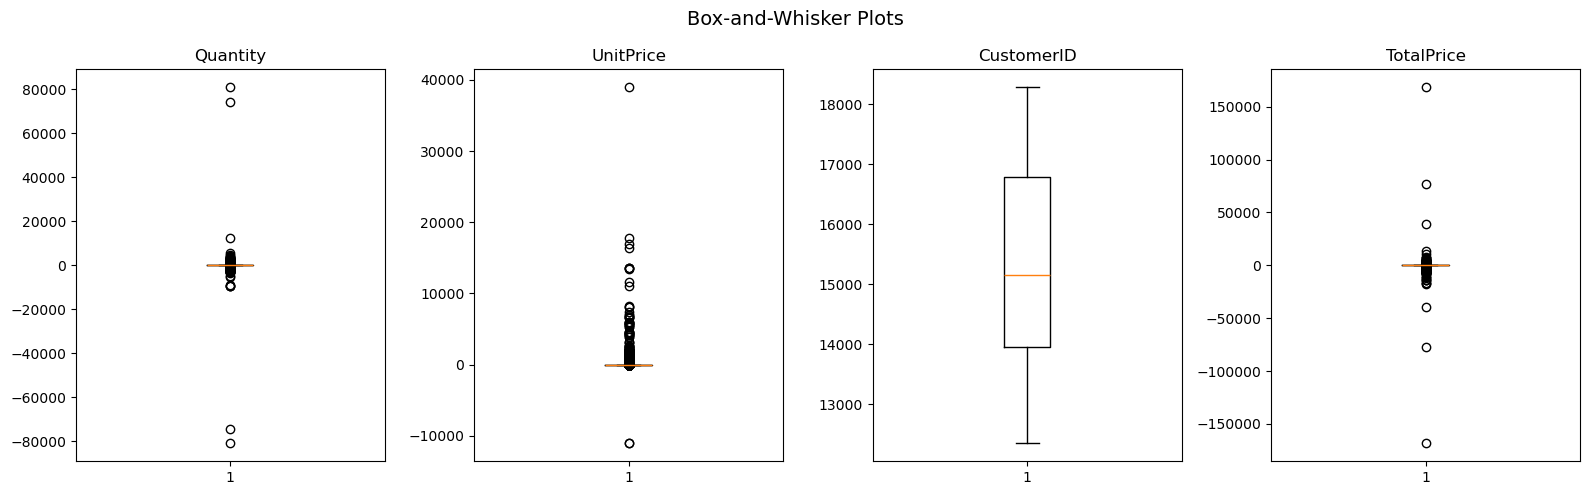

In [5]:
# --- Box-and-Whisker Plot ---
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Box-and-Whisker Plots', fontsize=14)
plt.tight_layout()
plt.show()

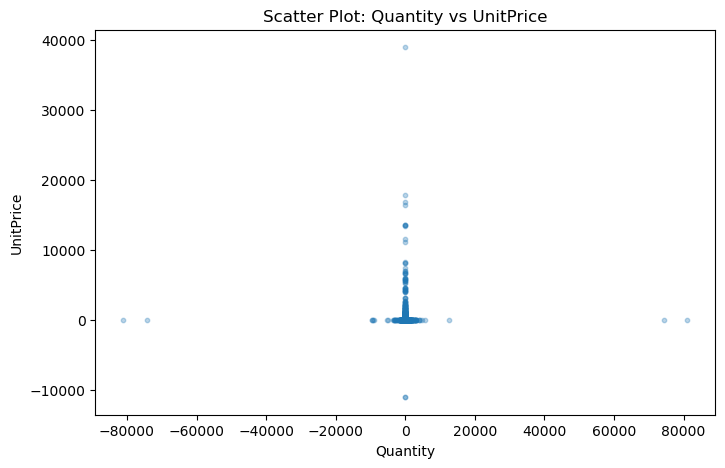

In [6]:
# --- Scatter Plot (Quantity vs UnitPrice) ---
plt.figure(figsize=(8, 5))
plt.scatter(df['Quantity'], df['UnitPrice'], alpha=0.3, s=10)
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter Plot: Quantity vs UnitPrice')
plt.show()

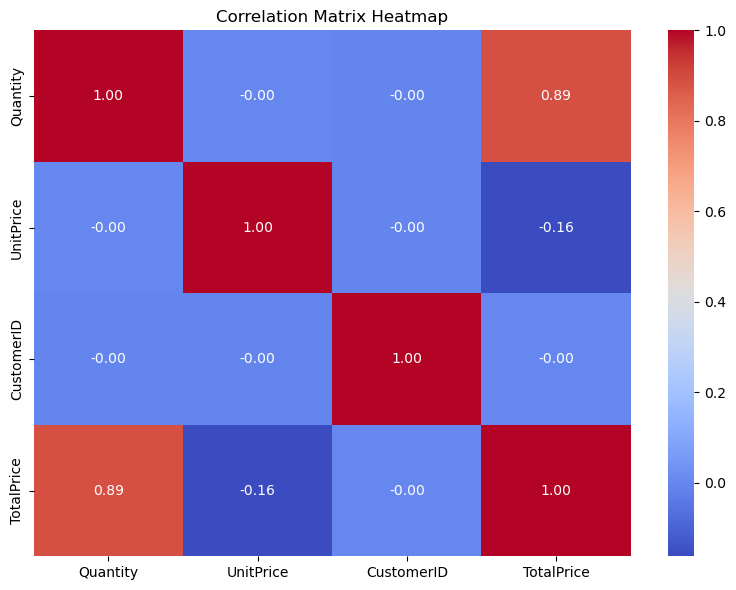

In [7]:
# --- Correlation Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

## Part B: Inferential Statistics

### B1: Distributions — Normal, Poisson, Population Parameters, Sampling Errors, Confidence Intervals

Population Parameters (UnitPrice): Mean = 4.61, Std Dev = 96.76


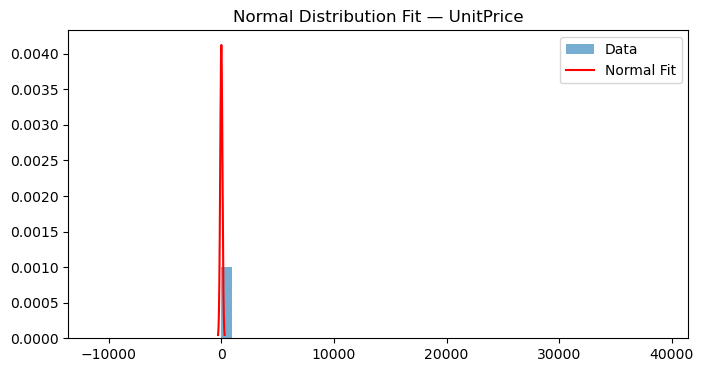

Shapiro-Wilk Test: stat=0.1872, p-value=0.0000
Not Normal


In [8]:
# --- Normal Distribution fit on UnitPrice ---
data = df['UnitPrice'].dropna()
mu, sigma = data.mean(), data.std()

print(f"Population Parameters (UnitPrice): Mean = {mu:.2f}, Std Dev = {sigma:.2f}")

# Fit and plot normal distribution
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 200)
plt.figure(figsize=(8, 4))
plt.hist(data, bins=50, density=True, alpha=0.6, label='Data')
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', label='Normal Fit')
plt.title('Normal Distribution Fit — UnitPrice')
plt.legend()
plt.show()

# Shapiro-Wilk test for normality (on sample)
sample = data.sample(500, random_state=42)
stat, p = stats.shapiro(sample)
print(f"Shapiro-Wilk Test: stat={stat:.4f}, p-value={p:.4f}")
print("Normal" if p > 0.05 else "Not Normal")

Poisson Lambda (Quantity): 10.66


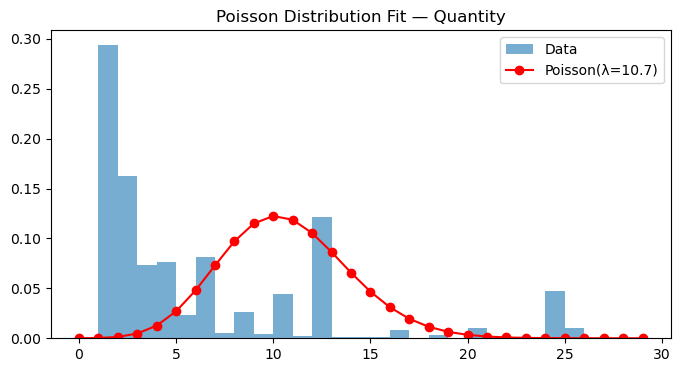

In [9]:
# --- Poisson Distribution fit on Quantity ---
qty = df['Quantity'][df['Quantity'] > 0].dropna()
lam = qty.mean()
print(f"Poisson Lambda (Quantity): {lam:.2f}")

x_pois = np.arange(0, 30)
plt.figure(figsize=(8, 4))
plt.hist(qty, bins=range(0, 30), density=True, alpha=0.6, label='Data')
plt.plot(x_pois, stats.poisson.pmf(x_pois, lam), 'ro-', label=f'Poisson(λ={lam:.1f})')
plt.title('Poisson Distribution Fit — Quantity')
plt.legend()
plt.show()

In [10]:
# --- Sampling Error & Confidence Intervals ---
pop_mean = df['UnitPrice'].mean()
sample = df['UnitPrice'].dropna().sample(500, random_state=42)
sample_mean = sample.mean()
sampling_error = abs(pop_mean - sample_mean)

# 95% Confidence Interval
ci = stats.t.interval(0.95, len(sample)-1, loc=sample_mean, scale=stats.sem(sample))

print(f"Population Mean: {pop_mean:.4f}")
print(f"Sample Mean:     {sample_mean:.4f}")
print(f"Sampling Error:  {sampling_error:.4f}")
print(f"95% Confidence Interval: ({ci[0]:.4f}, {ci[1]:.4f})")

Population Mean: 4.6111
Sample Mean:     3.9352
Sampling Error:  0.6759
95% Confidence Interval: (2.9797, 4.8908)


### B2: Hypothesis Testing — Z-test, t-test, Type I & II Error, ANOVA

In [11]:
# --- Z-Test ---
# H0: Sample mean of UnitPrice = Population mean
from statsmodels.stats.weightstats import ztest

sample = df['UnitPrice'].dropna().sample(500, random_state=42)
z_stat, z_pval = ztest(sample, value=df['UnitPrice'].mean())

print("=== Z-Test ===")
print(f"H0: Sample mean = Population mean ({df['UnitPrice'].mean():.2f})")
print(f"Z-statistic: {z_stat:.4f}, p-value: {z_pval:.4f}")
print("Reject H0" if z_pval < 0.05 else "Fail to reject H0")

=== Z-Test ===
H0: Sample mean = Population mean (4.61)
Z-statistic: -1.3897, p-value: 0.1646
Fail to reject H0


In [12]:
# --- T-Test ---
# Compare UnitPrice between two countries
uk = df[df['Country'] == 'United Kingdom']['UnitPrice'].dropna().sample(500, random_state=1)
fr = df[df['Country'] == 'France']['UnitPrice'].dropna()

t_stat, t_pval = stats.ttest_ind(uk, fr)

print("=== Independent T-Test ===")
print("H0: Mean UnitPrice (UK) = Mean UnitPrice (France)")
print(f"T-statistic: {t_stat:.4f}, p-value: {t_pval:.4f}")
print("Reject H0" if t_pval < 0.05 else "Fail to reject H0")

=== Independent T-Test ===
H0: Mean UnitPrice (UK) = Mean UnitPrice (France)
T-statistic: -0.4713, p-value: 0.6374
Fail to reject H0


In [13]:
# --- Type I and Type II Error ---
alpha = 0.05  # significance level

print("=== Type I & Type II Error ===")
print(f"Significance level (α) = {alpha}")
print(f"Type I Error (False Positive): Rejecting H0 when it is true  → Probability = α = {alpha}")
print(f"Type II Error (False Negative): Failing to reject H0 when it is false → Probability = β")

# Estimate power (1 - β) for the t-test above
from statsmodels.stats.power import TTestIndPower
effect_size = (uk.mean() - fr.mean()) / np.sqrt((uk.var() + fr.var()) / 2)
power_analysis = TTestIndPower()
power = power_analysis.power(effect_size=abs(effect_size), nobs1=len(uk), ratio=len(fr)/len(uk), alpha=alpha)
beta = 1 - power

print(f"\nEffect size (Cohen's d): {effect_size:.4f}")
print(f"Power (1-β): {power:.4f}")
print(f"Type II Error (β): {beta:.4f}")

=== Type I & Type II Error ===
Significance level (α) = 0.05
Type I Error (False Positive): Rejecting H0 when it is true  → Probability = α = 0.05
Type II Error (False Negative): Failing to reject H0 when it is false → Probability = β

Effect size (Cohen's d): -0.0297
Power (1-β): 0.0991
Type II Error (β): 0.9009


In [14]:
# --- One-Way ANOVA ---
# Compare UnitPrice across top 4 countries
top_countries = df['Country'].value_counts().head(4).index.tolist()
groups = [df[df['Country'] == c]['UnitPrice'].dropna() for c in top_countries]

f_stat, anova_pval = stats.f_oneway(*groups)

print("=== One-Way ANOVA ===")
print(f"Comparing UnitPrice across: {top_countries}")
print(f"F-statistic: {f_stat:.4f}, p-value: {anova_pval:.4f}")
print("Reject H0 (means differ)" if anova_pval < 0.05 else "Fail to reject H0 (means are equal)")

=== One-Way ANOVA ===
Comparing UnitPrice across: ['United Kingdom', 'Germany', 'France', 'EIRE']
F-statistic: 0.7184, p-value: 0.5408
Fail to reject H0 (means are equal)


### Conclusion
- Descriptive statistics (central tendency, dispersion, shape) were computed for all numeric columns.
- Visualizations (Box plot, Scatter plot, Correlation heatmap) provided graphical insights.
- Inferential statistics confirmed distribution fits, confidence intervals, and hypothesis tests (Z-test, t-test, ANOVA) on the Customer Segmentation dataset.